# Flipkart Refrigerator Price Analysis using Python.

***Import Libraries:***

In [1]:
import pandas as pd
import numpy as np 
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

# 1.Search for relavant website

In [2]:
url="https://www.flipkart.com/search?q=refrigerator"

In [3]:
url="https://www.flipkart.com/search?q=refrigerator"
headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36"
    }

response=requests.get(url,headers=headers)
response


<Response [200]>

In [4]:
response.status_code

200

In [5]:
html_code=response.text

In [6]:
html_code[:2000]

'<!doctype html><html lang="en"><head><link href="https://rukminim2.flixcart.com" rel="preconnect"/><link rel="stylesheet" href="//static-assets-web.flixcart.com/fk-p-linchpin-web/fk-cp-zion/css/bundle.aa1465.css"/><link rel="stylesheet" href="//static-assets-web.flixcart.com/fk-p-linchpin-web/fk-cp-zion/css/bundle.fbaef9.css"/><meta http-equiv="Content-type" content="text/html; charset=utf-8"/><meta http-equiv="X-UA-Compatible" content="IE=Edge"/><meta property="fb:page_id" content="102988293558"/><meta property="fb:admins" content="658873552,624500995,100000233612389"/><link rel="shortcut icon" href="https://static-assets-web.flixcart.com/www/promos/new/20150528-140547-favicon-retina.ico"/><link type="application/opensearchdescription+xml" rel="search" href="/osdd.xml?v=2"/><meta property="og:type" content="website"/><meta name="og_site_name" property="og:site_name" content="Flipkart.com"/><link rel="apple-touch-icon" sizes="57x57" href="/apple-touch-icon-57x57.png"/><link rel="apple

In [7]:
soup = BeautifulSoup(html_code)

In [8]:
soup.text[:2000]

'  Refrigerator- Buy Products Online at Best Price in India - All Categories | Flipkart.com     Explore PlusLoginBecome a Seller More CartFiltersCATEGORIESHome & KitchenHome AppliancesRefrigerators?StarCapacityIdeal for Family SizeFamily of 5 or moreFamily of 4Family of 3CoupleSingleCustomer Ratings4★ & above3★ & above2★ & above1★ & aboveFeaturesPrice......Min₹15000₹25000₹40000₹60000to₹15000₹25000₹40000₹60000₹60000+TypeBrandLGWhirlpoolHaierSamsungGodrejMarQ by Flipkart26 MOREColorGST Invoice AvailableBEE Rating YearDefrosting TypeDiscountAvailabilityOffersSpecial PriceBuy More, Save MoreThemeNeed help?Help me decideHomeHome & KitchenHome AppliancesRefrigeratorsShowing 1 – 24 of 1,155 results for "refrigerator"Sort ByRelevancePopularityPrice -- Low to HighPrice -- High to LowNewest FirstDiscountAdd to CompareSamsung 183 L Direct Cool Single Door 2 Star Refrigerator4.51,33,477 Ratings\xa0&\xa08,681 ReviewsReciprocatingBuilt-in Stabilizer1 Year Comprehensive Warranty on Product and 10 Yea

 # 2.Extract data

In [9]:
title=soup.find("div",attrs={"class":"RG5Slk"})
title.text
                             

'Samsung 183 L Direct Cool Single Door 2 Star Refrigerator'

In [10]:
reviews=soup.find("span", attrs={"class":"PvbNMB"})
reviews.text

'1,33,477 Ratings\xa0&\xa08,681 Reviews'

In [11]:
feature_list= soup.find("ul",attrs={"class":"HwRTzP"})
feature_list.text

'ReciprocatingBuilt-in Stabilizer1 Year Comprehensive Warranty on Product and 10 Years Warranty on Compressor'

In [12]:
price=soup.find("div",attrs={"class":"hZ3P6w DeU9vF"})
price.text

'₹13,690'

In [13]:
discount=soup.find("div",attrs={"class":"HQe8jr"})
discount.text

'31% off'

In [14]:
rating=soup.find("div",attrs={"class":"MKiFS6"})
rating.text

'4.5'

In [15]:
import pandas as pd
import numpy as np

In [17]:
title_data=[]
review_data=[]
feature_data=[]
price_data=[]
discount_data=[]
rating_data=[]


for i in range(1,42):
    url=f'https://www.flipkart.com/search?q=refrigerator&page={i}'
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36"
    }
    response= requests.get(url,headers= headers)
    if response.status_code==403:
        print("There is a 403 Error!")
        break

    html_code = response.text
    soup= BeautifulSoup(html_code)
    containers= soup.find_all("div",attrs= {"class":"ZFwe0M row"})
    for c in containers:
        title= c.find("div",attrs={"class":"RG5Slk"})
        if title is None:
            title_data.append(np.nan)
        else:
            title_data.append(title.text)

        review=c.find("span",attrs={"class":"PvbNMB"})
        if review is None:
            review_data.append(np.nan)
        else:
            review_data.append(review.text)

        feature=c.find("ul",attrs={"class":"HwRTzP"})
        if feature is None:
            feature_data.append(np.nan)
        else:
            feature_data.append(feature.text)

        price=c.find("div",attrs={"class":"hZ3P6w DeU9vF"})
        if price is None:
            price_data.append(np.nan)
        else:
            price_data.append(price.text)


        rating=c.find("div",attrs={"class":"MKiFS6"})
        if rating is None:
            rating_data.append(np.nan)
        else:
            rating_data.append(rating.text)

        discount=c.find("div",attrs={"class":"HQe8jr"})
        if discount is None:
            discount_data.append(np.nan)
        else:
            discount_data.append(discount.text)
            

In [18]:
print("Product Title",len(title_data))
print("Product Review",len(review_data))
print("Product Features",len(feature_data))
print("Product Price",len(price_data))
print("Product Discount",len(discount_data))
print("Product Rating",len(rating_data))

Product Title 984
Product Review 984
Product Features 984
Product Price 984
Product Discount 984
Product Rating 984


# 3.Create a Data Frame

In [19]:
df=pd.DataFrame({"Product Title": title_data,
                 "Product Review": review_data,
                 "Product Features":feature_data,
                 "Product Price": price_data,
                 "Product Discount": discount_data,
                 "Product Rating":rating_data
                })

In [22]:
df.head()

,Product Title,Product Review,Product Features,Product Price,Product Discount,Product Rating,Brand
0,Samsung 183 L Direct Cool Single Door 2 Star R...,"1,33,477 Ratings & 8,681 Reviews",ReciprocatingBuilt-in Stabilizer1 Year Compreh...,"₹13,690",31% off,4.5,Samsung
1,Samsung 183 L Direct Cool Single Door 4 Star R...,"1,33,477 Ratings & 8,681 Reviews",ReciprocatingBuilt-in Stabilizer1 year compreh...,"₹15,990",30% off,4.5,Samsung
2,Haier 185 L Direct Cool Single Door 2 Star Ref...,"16,784 Ratings & 1,035 Reviews",Normal CompressorBuilt-in Stabilizer1 Year War...,"₹11,790",31% off,4.3,Haier
3,Samsung 183 L Direct Cool Single Door 4 Star R...,"1,33,477 Ratings & 8,681 Reviews",ReciprocatingBuilt-in Stabilizer1 year compreh...,"₹15,990",30% off,4.5,Samsung
4,Godrej 183 L Direct Cool Single Door 3 Star Re...,"9,859 Ratings & 545 Reviews",Reciprocatory CompressorBuilt-in Stabilizer1 Y...,"₹13,490",37% off,4.3,Godrej


In [25]:
import re 

In [26]:
df["Brand"] = df["Product Title"].apply(
    lambda x: x.split()[0] if pd.notna(x) else None
)

df["Capacity"] = df["Product Title"].apply(
    lambda x: re.search(r"\d+\s?L", x).group() if pd.notna(x) and re.search(r"\d+\s?L", x) else None
)

df["Energy_Rating"] = df["Product Title"].apply(
    lambda x: re.search(r"\d+\s?Star", x).group() if pd.notna(x) and re.search(r"\d+\s?Star", x) else None
)

In [27]:
df.head()

,Product Title,Product Review,Product Features,Product Price,Product Discount,Product Rating,Brand,Capacity,Energy_Rating
0,Samsung 183 L Direct Cool Single Door 2 Star R...,"1,33,477 Ratings & 8,681 Reviews",ReciprocatingBuilt-in Stabilizer1 Year Compreh...,"₹13,690",31% off,4.5,Samsung,183 L,2 Star
1,Samsung 183 L Direct Cool Single Door 4 Star R...,"1,33,477 Ratings & 8,681 Reviews",ReciprocatingBuilt-in Stabilizer1 year compreh...,"₹15,990",30% off,4.5,Samsung,183 L,4 Star
2,Haier 185 L Direct Cool Single Door 2 Star Ref...,"16,784 Ratings & 1,035 Reviews",Normal CompressorBuilt-in Stabilizer1 Year War...,"₹11,790",31% off,4.3,Haier,185 L,2 Star
3,Samsung 183 L Direct Cool Single Door 4 Star R...,"1,33,477 Ratings & 8,681 Reviews",ReciprocatingBuilt-in Stabilizer1 year compreh...,"₹15,990",30% off,4.5,Samsung,183 L,4 Star
4,Godrej 183 L Direct Cool Single Door 3 Star Re...,"9,859 Ratings & 545 Reviews",Reciprocatory CompressorBuilt-in Stabilizer1 Y...,"₹13,490",37% off,4.3,Godrej,183 L,3 Star


-- Changes to make 
-- Total rating , total review ( Product Review )

-- Warranty,( Product feature) 

In [29]:
# Extract total ratings and total reviews
df["Total_Ratings"] = (
    df["Product Review"]
    .str.extract(r"([\d,]+)\sRatings", expand= False)
    .str.replace(",", "", regex=True)
    .astype(float)
)

df["Total_Reviews"] = (
    df["Product Review"]
    .str.extract(r"&\s([\d,]+)\sReviews", expand=False)
    .str.replace(",", "", regex=True)
    .astype(float)
)

# Drop the original Product Review column
df.drop(columns=["Product Review"], inplace=True)

# Check result
df.head()

,Product Title,Product Features,Product Price,Product Discount,Product Rating,Brand,Capacity,Energy_Rating,Total_Ratings,Total_Reviews
0,Samsung 183 L Direct Cool Single Door 2 Star R...,ReciprocatingBuilt-in Stabilizer1 Year Compreh...,"₹13,690",31% off,4.5,Samsung,183 L,2 Star,133477.0,8681.0
1,Samsung 183 L Direct Cool Single Door 4 Star R...,ReciprocatingBuilt-in Stabilizer1 year compreh...,"₹15,990",30% off,4.5,Samsung,183 L,4 Star,133477.0,8681.0
2,Haier 185 L Direct Cool Single Door 2 Star Ref...,Normal CompressorBuilt-in Stabilizer1 Year War...,"₹11,790",31% off,4.3,Haier,185 L,2 Star,16784.0,1035.0
3,Samsung 183 L Direct Cool Single Door 4 Star R...,ReciprocatingBuilt-in Stabilizer1 year compreh...,"₹15,990",30% off,4.5,Samsung,183 L,4 Star,133477.0,8681.0
4,Godrej 183 L Direct Cool Single Door 3 Star Re...,Reciprocatory CompressorBuilt-in Stabilizer1 Y...,"₹13,490",37% off,4.3,Godrej,183 L,3 Star,9859.0,545.0


In [30]:
# Clean feature text
df["Product Features"] = df["Product Features"].astype(str)

# Compressor Type
df["Compressor_Type"] = df["Product Features"].str.extract(
    r"(Reciprocating|Normal|Inverter)\s*Compressor",
    expand=False
)

# Built-in Stabilizer
df["Built_in_Stabilizer"] = df["Product Features"].str.contains(
    "Stabilizer", case=False, na=False
).map({True: "Yes", False: "No"})

# Warranty (in years)
df["Warranty_Years"] = df["Product Features"].str.extract(
    r"(\d+)\s*Year",
    expand=False
).astype(float)

# Drop original column
df.drop(columns=["Product Features"], inplace=True)

df.head()

,Product Title,Product Price,Product Discount,Product Rating,Brand,Capacity,Energy_Rating,Total_Ratings,Total_Reviews,Compressor_Type,Built_in_Stabilizer,Warranty_Years
0,Samsung 183 L Direct Cool Single Door 2 Star R...,"₹13,690",31% off,4.5,Samsung,183 L,2 Star,133477.0,8681.0,NaN,Yes,1.0
1,Samsung 183 L Direct Cool Single Door 4 Star R...,"₹15,990",30% off,4.5,Samsung,183 L,4 Star,133477.0,8681.0,NaN,Yes,NaN
2,Haier 185 L Direct Cool Single Door 2 Star Ref...,"₹11,790",31% off,4.3,Haier,185 L,2 Star,16784.0,1035.0,Normal,Yes,1.0
3,Samsung 183 L Direct Cool Single Door 4 Star R...,"₹15,990",30% off,4.5,Samsung,183 L,4 Star,133477.0,8681.0,NaN,Yes,NaN
4,Godrej 183 L Direct Cool Single Door 3 Star Re...,"₹13,490",37% off,4.3,Godrej,183 L,3 Star,9859.0,545.0,NaN,Yes,1.0


In [31]:
df.drop(columns=["Compressor_Type"], inplace=True)

df.head()

,Product Title,Product Price,Product Discount,Product Rating,Brand,Capacity,Energy_Rating,Total_Ratings,Total_Reviews,Built_in_Stabilizer,Warranty_Years
0,Samsung 183 L Direct Cool Single Door 2 Star R...,"₹13,690",31% off,4.5,Samsung,183 L,2 Star,133477.0,8681.0,Yes,1.0
1,Samsung 183 L Direct Cool Single Door 4 Star R...,"₹15,990",30% off,4.5,Samsung,183 L,4 Star,133477.0,8681.0,Yes,NaN
2,Haier 185 L Direct Cool Single Door 2 Star Ref...,"₹11,790",31% off,4.3,Haier,185 L,2 Star,16784.0,1035.0,Yes,1.0
3,Samsung 183 L Direct Cool Single Door 4 Star R...,"₹15,990",30% off,4.5,Samsung,183 L,4 Star,133477.0,8681.0,Yes,NaN
4,Godrej 183 L Direct Cool Single Door 3 Star Re...,"₹13,490",37% off,4.3,Godrej,183 L,3 Star,9859.0,545.0,Yes,1.0


In [32]:
df.shape

(984, 11)

***1. How many features(Columns) do you have?***

The dataset contains 11 features (columns)

In [34]:
df.shape[0]

984

***2.How many observations(rows) do you have?***

The dataset contains 984 observations (rows).

In [35]:
df.dtypes

Product Title           object
Product Price           object
Product Discount        object
Product Rating          object
Brand                   object
Capacity                object
Energy_Rating           object
Total_Ratings          float64
Total_Reviews          float64
Built_in_Stabilizer     object
Warranty_Years         float64
dtype: object

***3.What is the data type of each feature(Columns)?***

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product Title        984 non-null    object 
 1   Product Price        984 non-null    object 
 2   Product Discount     955 non-null    object 
 3   Product Rating       895 non-null    object 
 4   Brand                984 non-null    object 
 5   Capacity             984 non-null    object 
 6   Energy_Rating        916 non-null    object 
 7   Total_Ratings        895 non-null    float64
 8   Total_Reviews        895 non-null    float64
 9   Built_in_Stabilizer  984 non-null    object 
 10  Warranty_Years       794 non-null    float64
dtypes: float64(3), object(8)
memory usage: 84.7+ KB


***4.How many missing values are there?***

In [37]:
df.isnull().sum()

Product Title            0
Product Price            0
Product Discount        29
Product Rating          89
Brand                    0
Capacity                 0
Energy_Rating           68
Total_Ratings           89
Total_Reviews           89
Built_in_Stabilizer      0
Warranty_Years         190
dtype: int64

In [38]:
df.isnull().sum().sum()

np.int64(554)

#  6. Clean the Data

Data cleaning is an important step to ensure accuracy and reliability of analysis. In this project, the dataset was cleaned by removing special characters, correcting formats,handling missing values,converting data types, and treating outliers.


***1.Checking incorrect headers.***

This check whether column names are readable and meaningful. if headers are incorrect or have spaces or symbols so that we can rename it.

special characters prevent numerical calculations can be replaced by using str.replace()

In [39]:
df.columns

Index(['Product Title', 'Product Price', 'Product Discount', 'Product Rating',
       'Brand', 'Capacity', 'Energy_Rating', 'Total_Ratings', 'Total_Reviews',
       'Built_in_Stabilizer', 'Warranty_Years'],
      dtype='object')

In [40]:
df.rename(columns={
    'Product Price': 'Price',
    'Product Rating': 'Rating',
    'Product Discount': 'Discount'
}, inplace=True)


***2.Removing Special characters.***

In [41]:
#6.1.Cleaning product_rating:
df['Rating'] = df['Rating'].astype(str)
df['Rating'] = df['Rating'].str.extract(r'(\d\.\d)')
df['Rating'] = df['Rating'].astype(float)


In [42]:
# cleaning product discount
df['Discount'] = df['Discount'].astype(str)
df['Discount'] = df['Discount'].str.extract(r'(\d+)')
df['Discount'] = df['Discount'].astype(float)


In [43]:
# cleaning product price
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('₹', '', regex=False)
df['Price'] = df['Price'].str.replace(',', '', regex=False)
df['Price'] = df['Price'].astype(float)


In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product Title     984 non-null    object 
 1   Product Review    896 non-null    object 
 2   Product Features  983 non-null    object 
 3   Price             984 non-null    float64
 4   Discount          962 non-null    float64
 5   Rating            878 non-null    float64
 6   Brand             984 non-null    object 
 7   Capacity          984 non-null    object 
 8   Energy_Rating     916 non-null    object 
dtypes: float64(3), object(6)
memory usage: 69.3+ KB


***3.Identifying Missing values***

In [44]:
df.isnull().sum()

Product Title            0
Price                    0
Discount                29
Rating                 100
Brand                    0
Capacity                 0
Energy_Rating           68
Total_Ratings           89
Total_Reviews           89
Built_in_Stabilizer      0
Warranty_Years         190
dtype: int64

In [45]:
df.isnull().sum().sum()

np.int64(565)

In [49]:
num_cols = ["Price", "Discount", "Rating"]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [50]:
most_common = df["Energy_Rating"].mode()[0]
df["Energy_Rating"].fillna(most_common, inplace=True)

In [52]:
df["Total_Ratings"].fillna(0, inplace=True)
df["Total_Reviews"].fillna(0, inplace=True)

In [53]:
df["Warranty_Years"].fillna(df["Warranty_Years"].median(), inplace=True)

In [54]:
df.isnull().sum()

Product Title          0
Price                  0
Discount               0
Rating                 0
Brand                  0
Capacity               0
Energy_Rating          0
Total_Ratings          0
Total_Reviews          0
Built_in_Stabilizer    0
Warranty_Years         0
dtype: int64

***4.fixing incorrect dataformats and invalid values:***

In [55]:
df.columns

Index(['Product Title', 'Price', 'Discount', 'Rating', 'Brand', 'Capacity',
       'Energy_Rating', 'Total_Ratings', 'Total_Reviews',
       'Built_in_Stabilizer', 'Warranty_Years'],
      dtype='object')

In [57]:
df['Price'] = df['Price'].astype(float)
df['Discount'] = df['Discount'].astype(float)
df['Rating'] = df['Rating'].astype(float)
df['Product Title'] = df['Product Title'].astype(str)

In [58]:
df["Capacity"] = (
    df["Capacity"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

In [59]:
df["Energy_Rating"] = (
    df["Energy_Rating"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

In [60]:
df.dtypes

Product Title           object
Price                  float64
Discount               float64
Rating                 float64
Brand                   object
Capacity               float64
Energy_Rating          float64
Total_Ratings          float64
Total_Reviews          float64
Built_in_Stabilizer     object
Warranty_Years         float64
dtype: object

In [61]:
df.head()

,Product Title,Price,Discount,Rating,Brand,Capacity,Energy_Rating,Total_Ratings,Total_Reviews,Built_in_Stabilizer,Warranty_Years
0,Samsung 183 L Direct Cool Single Door 2 Star R...,13690.0,31.0,4.5,Samsung,183.0,2.0,133477.0,8681.0,Yes,1.0
1,Samsung 183 L Direct Cool Single Door 4 Star R...,15990.0,30.0,4.5,Samsung,183.0,4.0,133477.0,8681.0,Yes,1.0
2,Haier 185 L Direct Cool Single Door 2 Star Ref...,11790.0,31.0,4.3,Haier,185.0,2.0,16784.0,1035.0,Yes,1.0
3,Samsung 183 L Direct Cool Single Door 4 Star R...,15990.0,30.0,4.5,Samsung,183.0,4.0,133477.0,8681.0,Yes,1.0
4,Godrej 183 L Direct Cool Single Door 3 Star Re...,13490.0,37.0,4.3,Godrej,183.0,3.0,9859.0,545.0,Yes,1.0


In [169]:
df.dtypes

Product Title        object
Product Review       object
Product Features     object
Price               float64
Discount            float64
Rating              float64
Brand                object
Capacity            float64
Energy_Rating       float64
dtype: object

***5.Remove Duplicates***

In [62]:
df.duplicated().sum() 

np.int64(428)

In [63]:
df.shape

(984, 11)

In [64]:
df.drop_duplicates(inplace=True)

In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df.shape

(556, 11)

***Duplicate entries in the data are bias analysis, so they are removed by using df.drop_duplicates.***

***After inspecting the dataset using isnull().sum(), it was observed that there were no missing values and duplicates present in any of the columns. Hence, no imputation or removal was required, and the dataset is directly used for further analysis.***

***6. Check Cleaned Data:***

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 556 entries, 0 to 983
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product Title        556 non-null    object 
 1   Price                556 non-null    float64
 2   Discount             556 non-null    float64
 3   Rating               556 non-null    float64
 4   Brand                556 non-null    object 
 5   Capacity             556 non-null    float64
 6   Energy_Rating        556 non-null    float64
 7   Total_Ratings        556 non-null    float64
 8   Total_Reviews        556 non-null    float64
 9   Built_in_Stabilizer  556 non-null    object 
 10  Warranty_Years       556 non-null    float64
dtypes: float64(8), object(3)
memory usage: 52.1+ KB


In [68]:
df.shape

(556, 11)

In [69]:
df.describe()

,Price,Discount,Rating,Capacity,Energy_Rating,Total_Ratings,Total_Reviews,Warranty_Years
count,556.000000,556.000000,556.000000,556.000000,556.000000,556.000000,556.000000,556.000000
mean,26117.884892,27.390288,4.271043,247.852518,2.933453,6583.609712,455.789568,1.201439
std,18165.451900,10.243021,0.243413,114.065177,1.148864,18747.006275,1233.740172,1.114555
min,5336.000000,1.000000,2.700000,4.000000,1.000000,0.000000,0.000000,1.000000
25%,16197.500000,21.000000,4.200000,185.000000,2.000000,10.750000,1.000000,1.000000
50%,19490.000000,28.000000,4.300000,207.000000,3.000000,386.500000,34.000000,1.000000
75%,27230.000000,34.000000,4.400000,253.000000,4.000000,5448.000000,402.000000,1.000000
max,135990.000000,55.000000,4.900000,695.000000,5.000000,133477.000000,8681.000000,10.000000


In [70]:
df.to_csv("Clean_data_Refrigerator17022026.csv", index=False)

In [72]:
df= pd.read_csv("C:/Users/bhavna daud/Downloads/Clean_data_Refrigerator17022026.xls")
df.head()

,Product Title,Price,Discount,Rating,Brand,Capacity,Energy_Rating,Total_Ratings,Total_Reviews,Built_in_Stabilizer,Warranty_Years
0,Samsung 183 L Direct Cool Single Door 2 Star R...,13690.0,31.0,4.5,Samsung,183.0,2.0,133477.0,8681.0,Yes,1.0
1,Samsung 183 L Direct Cool Single Door 4 Star R...,15990.0,30.0,4.5,Samsung,183.0,4.0,133477.0,8681.0,Yes,1.0
2,Haier 185 L Direct Cool Single Door 2 Star Ref...,11790.0,31.0,4.3,Haier,185.0,2.0,16784.0,1035.0,Yes,1.0
3,Godrej 183 L Direct Cool Single Door 3 Star Re...,13490.0,37.0,4.3,Godrej,183.0,3.0,9859.0,545.0,Yes,1.0
4,Godrej 194 L Direct Cool Single Door 5 Star Re...,15790.0,41.0,4.3,Godrej,194.0,5.0,11913.0,756.0,Yes,1.0


In [73]:
df.tail()

,Product Title,Price,Discount,Rating,Brand,Capacity,Energy_Rating,Total_Ratings,Total_Reviews,Built_in_Stabilizer,Warranty_Years
551,BOSCH 508 L Frost Free Double Door 2 Star Refr...,76990.0,25.0,4.3,BOSCH,508.0,2.0,0.0,0.0,Yes,1.0
552,Whirlpool 190 L Direct Cool Single Door 2 Star...,15748.0,1.0,4.3,Whirlpool,190.0,2.0,9868.0,809.0,Yes,1.0
553,Whirlpool 192 L Direct Cool Single Door 3 Star...,16990.0,24.0,4.3,Whirlpool,192.0,3.0,0.0,0.0,No,1.0
554,Samsung 224 L Frost Free Double Door 2 Star Re...,32499.0,22.0,4.3,Samsung,224.0,2.0,7.0,1.0,Yes,1.0
555,LG 343 L Frost Free Double Door 3 Star Convert...,52077.0,11.0,3.3,LG,343.0,3.0,7.0,0.0,Yes,1.0


***Identifying and treating outliers***

Treat outliers(IQR Method)

In [74]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower_limit) & (df['Price'] <= upper_limit)]

IQR method removes extremely high or low price values and it keeps realistic refrigerators only.

In [75]:
df.shape

(494, 11)

***Observation:***

This dataset contains 472 rows and 9 columns. All columns contain non null values, it means that there is no missing data.
Textual attributes are stored as object types, while numerical such as price, discount, rating, reviews are stored in numeric formats.
The dataset is clean and ready for EDA analysis.
    

# 7. Data Analysis and Visualization (EDA) 


In [76]:
#1. import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


***1.Univariate Analysis (analysis of single variable at a time)***

In [77]:
# A.continuous variable
#1.central tendency and dispersion( price)
df["Price"].describe()

count      494.000000
mean     20723.159919
std       7508.158009
min       5336.000000
25%      15982.500000
50%      18704.500000
75%      24082.250000
max      43500.000000
Name: Price, dtype: float64

In [78]:
df.columns

Index(['Product Title', 'Price', 'Discount', 'Rating', 'Brand', 'Capacity',
       'Energy_Rating', 'Total_Ratings', 'Total_Reviews',
       'Built_in_Stabilizer', 'Warranty_Years'],
      dtype='object')

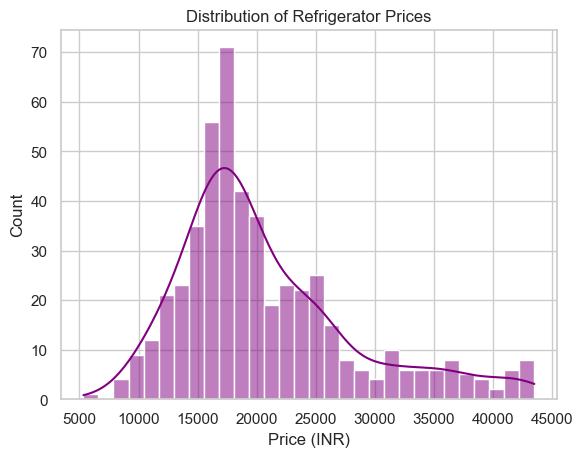

In [97]:
# Price Distribution:
sns.histplot(
    df["Price"], 
    bins=30, 
    kde=True,
    color="Purple"
)
    
plt.title("Distribution of Refrigerator Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Count")
plt.show()

This graph shows the distribution of refrigerator prices collected from Flipkart using web scraping.
+ The X-axis represents the price range (in INR).
+ The Y-axis shows the number of refrigerators available in each price range.

-- Observations
+ Most refrigerators are priced between ₹14,000 and ₹20,000, which forms the peak of the distribution.
+ This indicates that the mid-range segment dominates the market, suggesting higher consumer demand in this price range.
+ As prices increase beyond ₹25,000, the number of products gradually decreases, showing fewer premium models.
+ Very few refrigerators are available above ₹35,000–₹40,000, indicating a limited high-end segment.

-- Shape of the Distribution
+ The curve is right-skewed (positively skewed).
+ This means most products are concentrated at lower to mid prices, with a long tail toward higher prices.
+ The smooth line (KDE curve) helps visualize the overall price trend and confirms the skewness.

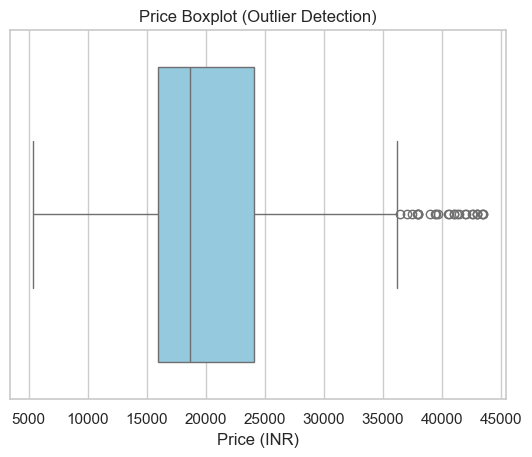

In [80]:
#Price boxplot (outliers)
sns.boxplot(
    x=df["Price"], 
   color="skyblue"
)
plt.title("Price Boxplot (Outlier Detection)")
plt.xlabel("Price (INR)")
plt.show()

This boxplot represents the distribution of refrigerator prices and is mainly used to identify outliers.
+ The box shows the interquartile range (IQR), which contains the middle 50% of prices.
+ The line inside the box represents the median price, which is around ₹18,000–₹19,000.
+ The left whisker indicates the lower price range, while the right whisker shows the upper price range excluding outliers.

-- Key Observations
+ Most refrigerator prices lie between ₹15,000 and ₹25,000, confirming that the mid-price segment dominates.


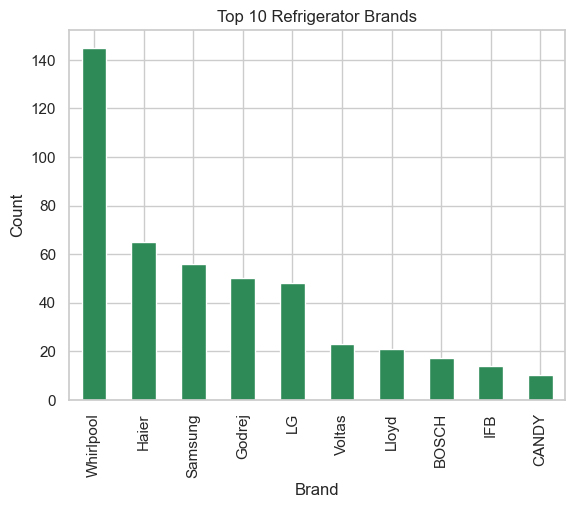

In [81]:
#Brand frequency 
df["Brand"].value_counts().head(10).plot(
    kind="bar", color="seagreen"
)
plt.title("Top 10 Refrigerator Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()

This bar chart shows the top 10 refrigerator brands available on Flipkart based on the number of products listed.
+ The X-axis represents the brand names.
+ The Y-axis represents the count of refrigerator models for each brand.

-- Key Observations
+ Whirlpool clearly dominates the market with the highest number of listings, indicating a strong product presence on Flipkart.
+ Haier, Samsung, and LG follow next, showing consistent and competitive market availability.
+ Godrej also has a significant presence, reflecting its popularity in the Indian market.
+ A higher number of listings often indicates strong brand reach and consumer demand.
+ Brands with fewer models may focus on specific segments, such as premium appliances or limited-capacity offerings.

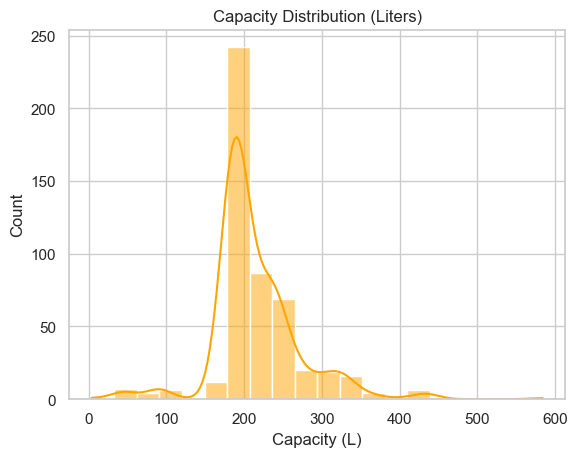

In [82]:
#capacity distribution 
sns.histplot(df["Capacity"], bins=20, kde=True, color="orange")
plt.title("Capacity Distribution (Liters)")
plt.xlabel("Capacity (L)")
plt.ylabel("Count")
plt.show()

This histogram shows the distribution of refrigerator capacities available on Flipkart.
+ The X-axis represents capacity in liters.
+ The Y-axis represents the number of refrigerator models in each capacity range.
+ The smooth line (KDE curve) shows the overall trend of capacity distribution.

-- Key Observations
+ Most refrigerators fall in the 180–220 liter range, which is the peak of the distribution.
+ This capacity range is typically preferred by small to medium-sized households, explaining its dominance.
+ As capacity increases beyond 250 liters, the number of available models gradually decreases.
+ Very large refrigerators (400+ liters) are rare, indicating a limited premium or large-family segment.


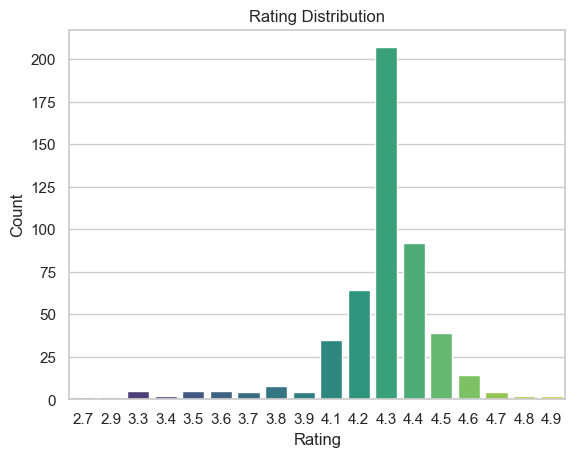

In [83]:
#rating distribution 
sns.countplot(x=df["Rating"], palette="viridis")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

This bar chart shows the distribution of customer ratings for refrigerators available on Flipkart.
+ The X-axis represents the average product rating.
+ The Y-axis shows the number of refrigerator models for each rating value.

-- Key Observations
+ Most refrigerators are rated between 4.2 and 4.4, with 4.3 being the most frequent rating.
+ This indicates overall high customer satisfaction across the platform.
+ Very few products have ratings below 4.0, suggesting low-rated products are either rare or less visible.
+ A smaller number of models have very high ratings (4.6–4.9), representing top-performing or premium products.

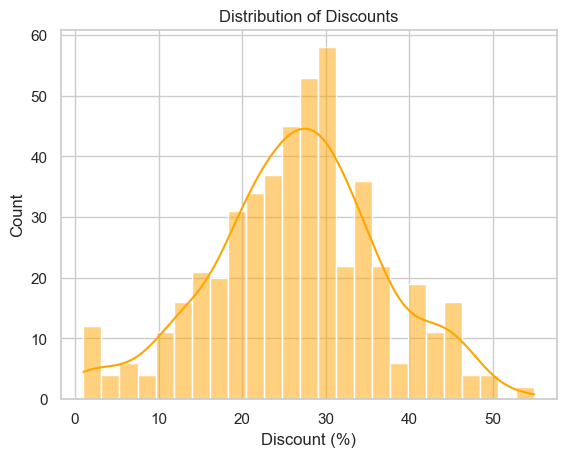

In [84]:
#Discount distribution
sns.histplot(df["Discount"], bins=25, kde=True, color="orange")
plt.title("Distribution of Discounts")
plt.xlabel("Discount (%)")
plt.ylabel("Count")
plt.show()

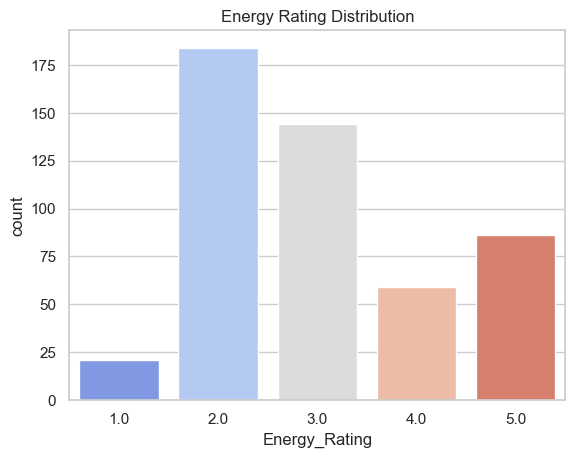

In [85]:
#Energy Rating distribution
sns.countplot(x=df["Energy_Rating"], palette="coolwarm")
plt.title("Energy Rating Distribution")
plt.show()

***Bivariate analysis***

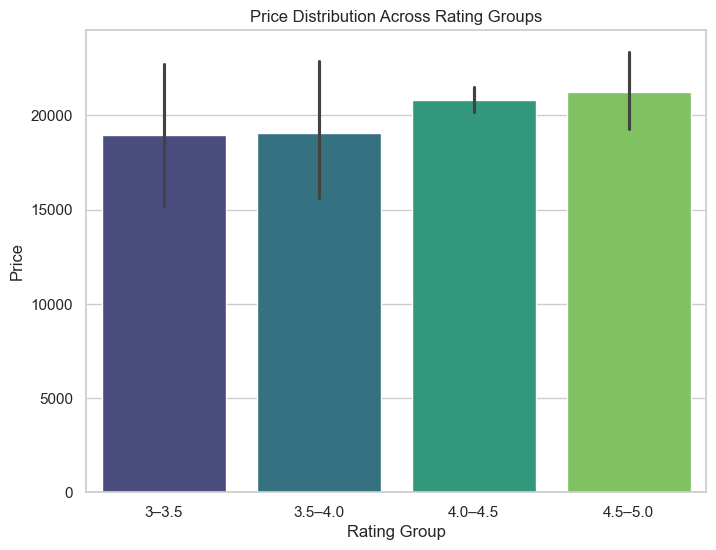

In [86]:
# Price Vs Rating
df["Rating_Group"] = pd.cut(
    df["Rating"],
    bins=[3, 3.5, 4.0, 4.5, 5.0],
    labels=["3–3.5", "3.5–4.0", "4.0–4.5", "4.5–5.0"]
)

plt.figure(figsize=(8,6))
sns.barplot(x="Rating_Group", y="Price", data=df, palette="viridis")

plt.title("Price Distribution Across Rating Groups")
plt.xlabel("Rating Group")
plt.ylabel("Price")
plt.show()

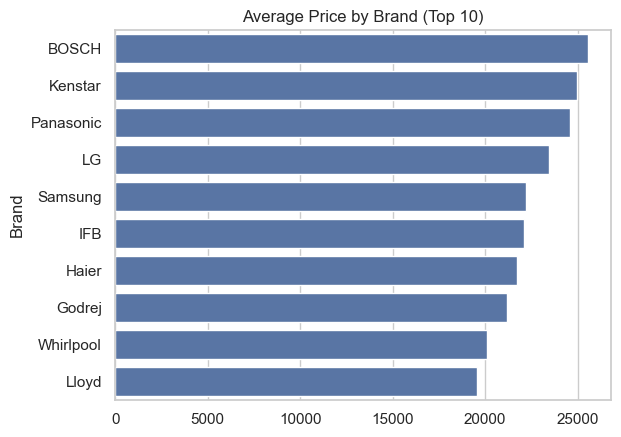

In [87]:
#Average Price vs Brand 
brand_price = df.groupby("Brand")["Price"].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=brand_price.values, 
    y=brand_price.index
)

plt.title("Average Price by Brand (Top 10)")
plt.show()

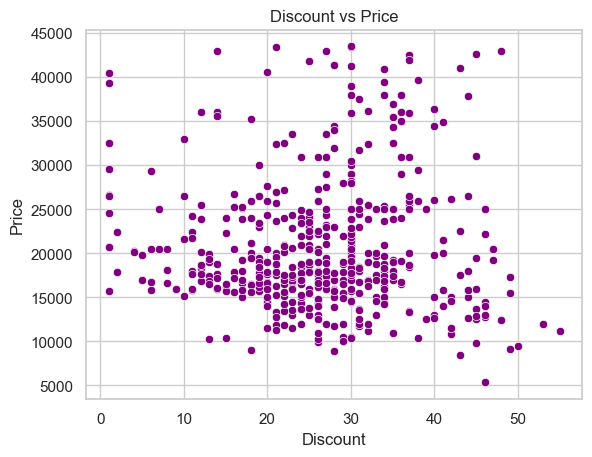

In [88]:
#Price vs Discount 
sns.scatterplot(
    x="Discount", 
    y="Price", 
    data=df, 
    color="purple"
)

plt.title("Discount vs Price")
plt.show()

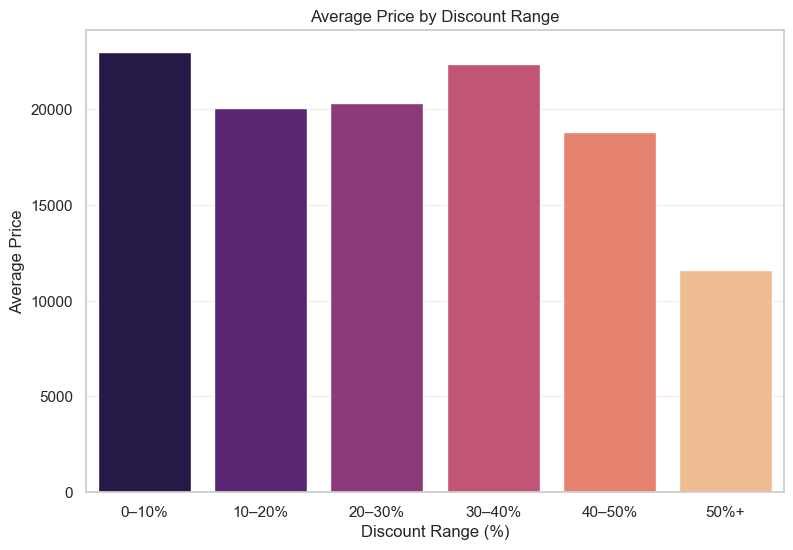

In [89]:
#Price vs Discount 
df["Discount_Range"] = pd.cut(
    df["Discount"],
    bins=[0, 10, 20, 30, 40, 50, 100],
    labels=["0–10%", "10–20%", "20–30%", "30–40%", "40–50%", "50%+"]
)
avg_discount_range =( df.groupby("Discount_Range")["Price"].mean().reset_index())

plt.figure(figsize=(9,6))
sns.barplot(
    x="Discount_Range",
    y="Price",
    data=avg_discount_range,
    palette="magma"
)

plt.title("Average Price by Discount Range")
plt.xlabel("Discount Range (%)")
plt.ylabel("Average Price")
plt.grid(axis="y", alpha=0.3)
plt.show()

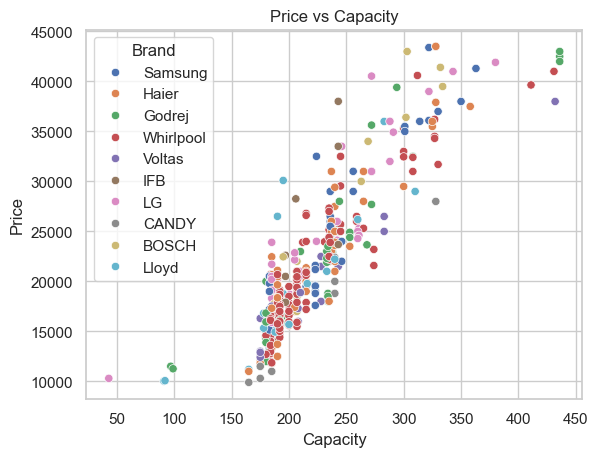

In [90]:
#Price vs capacity
top_brands= df["Brand"].value_counts().head(10).index
df_top10=df[df["Brand"].isin(top_brands)]

sns.scatterplot(
    x="Capacity", 
    y="Price", 
    data=df_top10, 
    hue="Brand")

plt.title("Price vs Capacity")
plt.show()

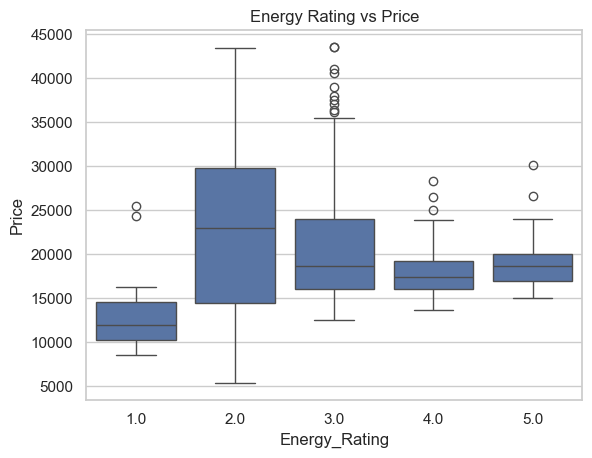

In [91]:
#Price vs Energy rating 
sns.boxplot(x="Energy_Rating", y="Price", data=df)
plt.title("Energy Rating vs Price")
plt.show()

***Multivariate analysis***

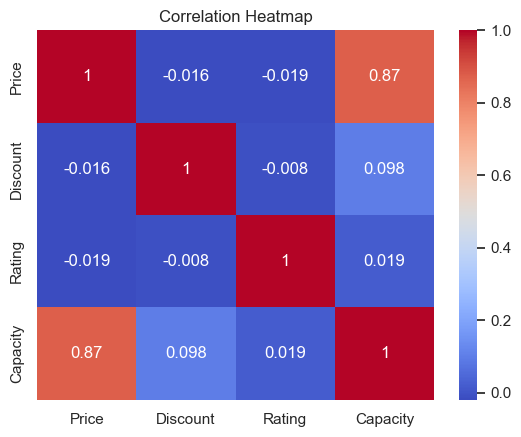

In [92]:
#Correlation Heatmap (Numeric Features)
numeric_cols = ["Price", "Discount", "Rating", "Capacity"]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [93]:
df.shape

(494, 13)

In [94]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
549    False
550    False
552    False
553    False
554    False
Length: 494, dtype: bool

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 494 entries, 0 to 554
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Product Title        494 non-null    object  
 1   Price                494 non-null    float64 
 2   Discount             494 non-null    float64 
 3   Rating               494 non-null    float64 
 4   Brand                494 non-null    object  
 5   Capacity             494 non-null    float64 
 6   Energy_Rating        494 non-null    float64 
 7   Total_Ratings        494 non-null    float64 
 8   Total_Reviews        494 non-null    float64 
 9   Built_in_Stabilizer  494 non-null    object  
 10  Warranty_Years       494 non-null    float64 
 11  Rating_Group         492 non-null    category
 12  Discount_Range       494 non-null    category
dtypes: category(2), float64(8), object(3)
memory usage: 47.7+ KB
